# Quick Start

This tutorial will show you the minimal steps to simulate stellar light curves using SAJAX, for a variety of configurations.

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import jax
import jax.numpy as jnp
from sajax import compute_light_curve, compute_combined_light_curve

# Set random seed for reproducibility
np.random.seed(42)

print("JAX version:", jax.__version__)
print("Available devices:", jax.devices())

JAX version: 0.9.1
Available devices: [CpuDevice(id=0)]


## Load Data from Files

In [2]:
# Load spectra (wavelength, flux_quiet, flux_active)
spectra_data = np.loadtxt('../_static/input_spectrum.txt', skiprows=1)
wavelength = spectra_data[:, 0]
flux_quiet = spectra_data[:, 1]
flux_active = spectra_data[:, 2]

# Load wavelength-dependent limb-darkening coefficients
ld_data = np.loadtxt('../_static/ldc.txt', skiprows=1) 
u1_wavelength = ld_data[:, 0]
u2_wavelength = ld_data[:, 1]

# Verify data alignment
print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Wavelength range:     {wavelength.min():.3f} - {wavelength.max():.3f} μm")
print(f"N wavelengths:        {len(wavelength)}")
print(f"Flux quiet range:     {flux_quiet.min():.4f} - {flux_quiet.max():.4f}")
print(f"Flux active range:    {flux_active.min():.4f} - {flux_active.max():.4f}")
print(f"LD u1 range:          {u1_wavelength.min():.3f} - {u1_wavelength.max():.3f}")
print(f"LD u2 range:          {u2_wavelength.min():.3f} - {u2_wavelength.max():.3f}")
print("=" * 60)

DATA SUMMARY
Wavelength range:     3010.000 - 9980.000 μm
N wavelengths:        698
Flux quiet range:     0.0115 - 1.0000
Flux active range:    0.0006 - 0.2926
LD u1 range:          0.368 - 1.721
LD u2 range:          -0.785 - 0.198


## Visualize Input Spectra and LD Coefficients

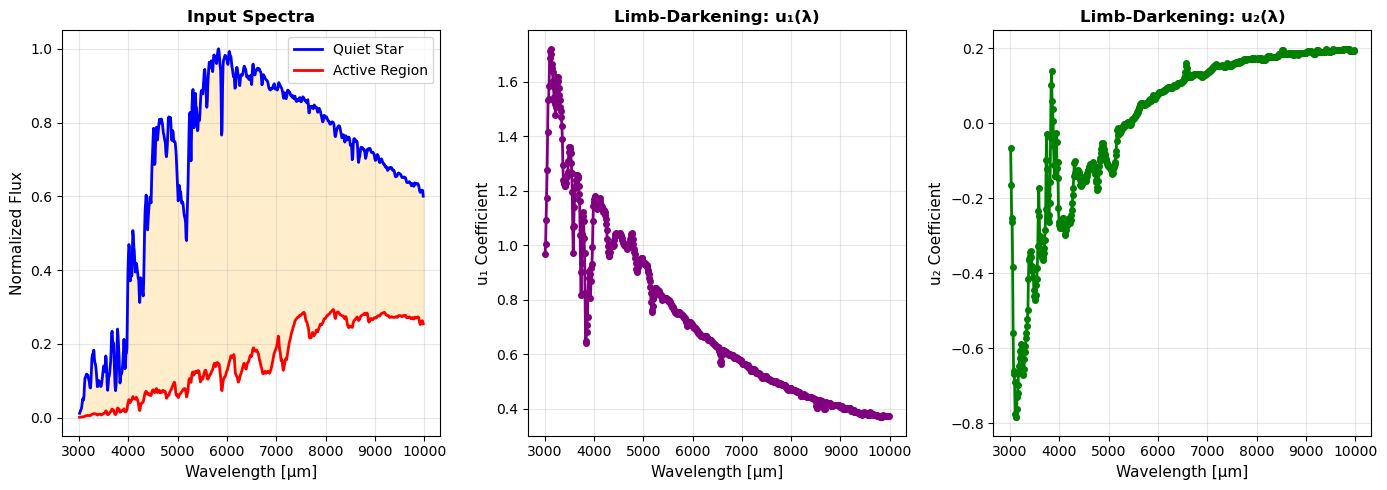


Mean spectral contrast (active region):  77.0%


In [3]:
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, figure=fig)

# Plot 1: Spectra
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(wavelength, flux_quiet, 'b-', linewidth=2, label='Quiet Star')
ax1.plot(wavelength, flux_active, 'r-', linewidth=2, label='Active Region')
ax1.fill_between(wavelength, flux_quiet, flux_active, alpha=0.2, color='orange')
ax1.set_xlabel('Wavelength [μm]', fontsize=11)
ax1.set_ylabel('Normalized Flux', fontsize=11)
ax1.set_title('Input Spectra', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: LD u1 coefficient
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(wavelength, u1_wavelength, 'o-', linewidth=2, color='purple', markersize=4)
ax2.set_xlabel('Wavelength [μm]', fontsize=11)
ax2.set_ylabel('u₁ Coefficient', fontsize=11)
ax2.set_title('Limb-Darkening: u₁(λ)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: LD u2 coefficient
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(wavelength, u2_wavelength, 'o-', linewidth=2, color='green', markersize=4)
ax3.set_xlabel('Wavelength [μm]', fontsize=11)
ax3.set_ylabel('u₂ Coefficient', fontsize=11)
ax3.set_title('Limb-Darkening: u₂(λ)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print spectrum contrast
contrast = (np.mean(flux_quiet) - np.mean(flux_active)) / np.mean(flux_quiet)
print(f"\nMean spectral contrast (active region):  {contrast*100:.1f}%")

## Case 1 - Single Spot, Basic Configuration


CASE 1: Single Spot - Basic Configuration
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)


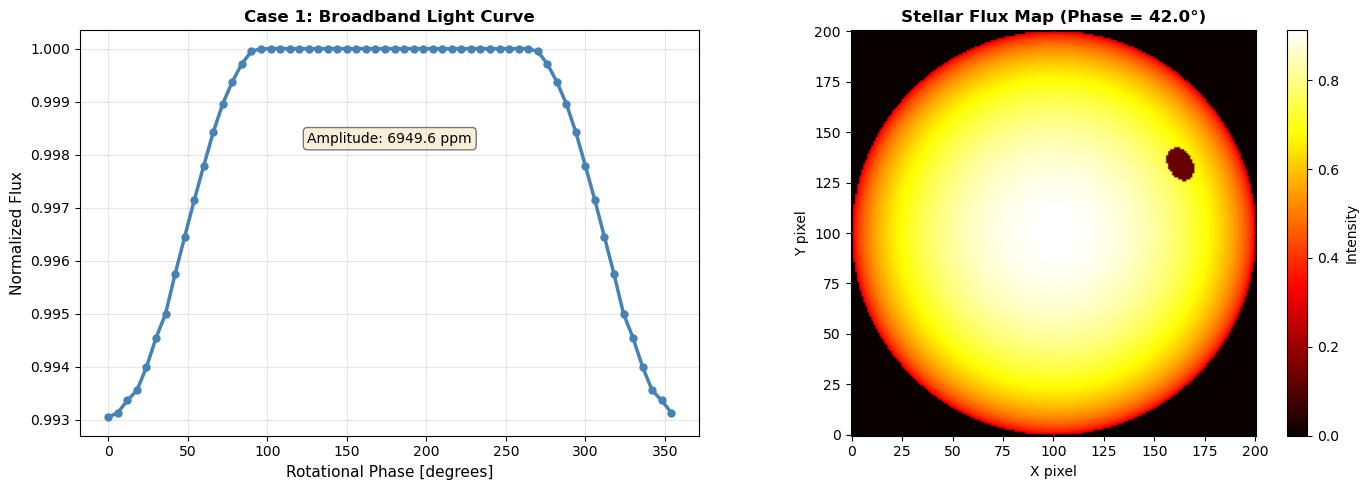


Results:
  Broadband LC amplitude:  6949.60 ppm


In [4]:
print("\n" + "="*60)
print("CASE 1: Single Spot - Basic Configuration")
print("="*60)

# Use mean LD coefficients
u1_mean = np.mean(u1_wavelength)
u2_mean = np.mean(u2_wavelength)

params_case1 = dict(
    ldc_coeffs = [u1_mean, u2_mean],   # quadratic law: [u1, u2]
    inc_star   = 90.0,                 # Equator-on view
)

result_case1 = compute_light_curve(
    wavelength          = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active,
    params              = params_case1,
    ar_lat              = [20.0],                    # Single spot at 20° lat
    ar_long             = [0.0],                     # Single spot at 0° long
    ar_size             = [5.0],                     # 5° radius
    phases_rot          = np.linspace(0, 360, 60, endpoint=False),
    stellar_grid_size   = 100,                       # stellar radius in pixels
    ve                  = 2.0,                       # Equatorial velocity [km/s]
    ldc_mode            = "quadratic",
    plot_map_wavelength = np.mean(wavelength),
)

phases = np.linspace(0, 360, 60, endpoint=False)

# Plot light curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Broadband light curve
ax = axes[0]
ax.plot(phases, result_case1["lc"], 'o-', linewidth=2.5,
        markersize=5, color='steelblue')
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Case 1: Broadband Light Curve', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

lc_amplitude = np.max(result_case1["lc"]) - np.min(result_case1["lc"])
ax.text(0.5, 0.75, f'Amplitude: {lc_amplitude*1e6:.1f} ppm',
        transform=ax.transAxes, ha='center', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Stellar flux map at a single phase
ax = axes[1]
phase_idx = np.argmin(np.abs(phases - 45))
star_maps = result_case1["star_maps"]
map_data  = star_maps[phase_idx]
im = ax.imshow(map_data, cmap='hot', origin='lower')
ax.set_title(f'Stellar Flux Map (Phase = {phases[phase_idx]:.1f}°)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('X pixel', fontsize=10)
ax.set_ylabel('Y pixel', fontsize=10)
plt.colorbar(im, ax=ax, label='Intensity')

plt.tight_layout()
plt.show()

print(f"\nResults:")
print(f"  Broadband LC amplitude:  {lc_amplitude*1e6:.2f} ppm")

## Case 2 - Multiple Spots at Different Latitudes


CASE 2: Multiple Spots
Per-AR flux scaling factors: [0.7, 0.85, 1.1]
flux_active_multi shape:     (3, 698)
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)


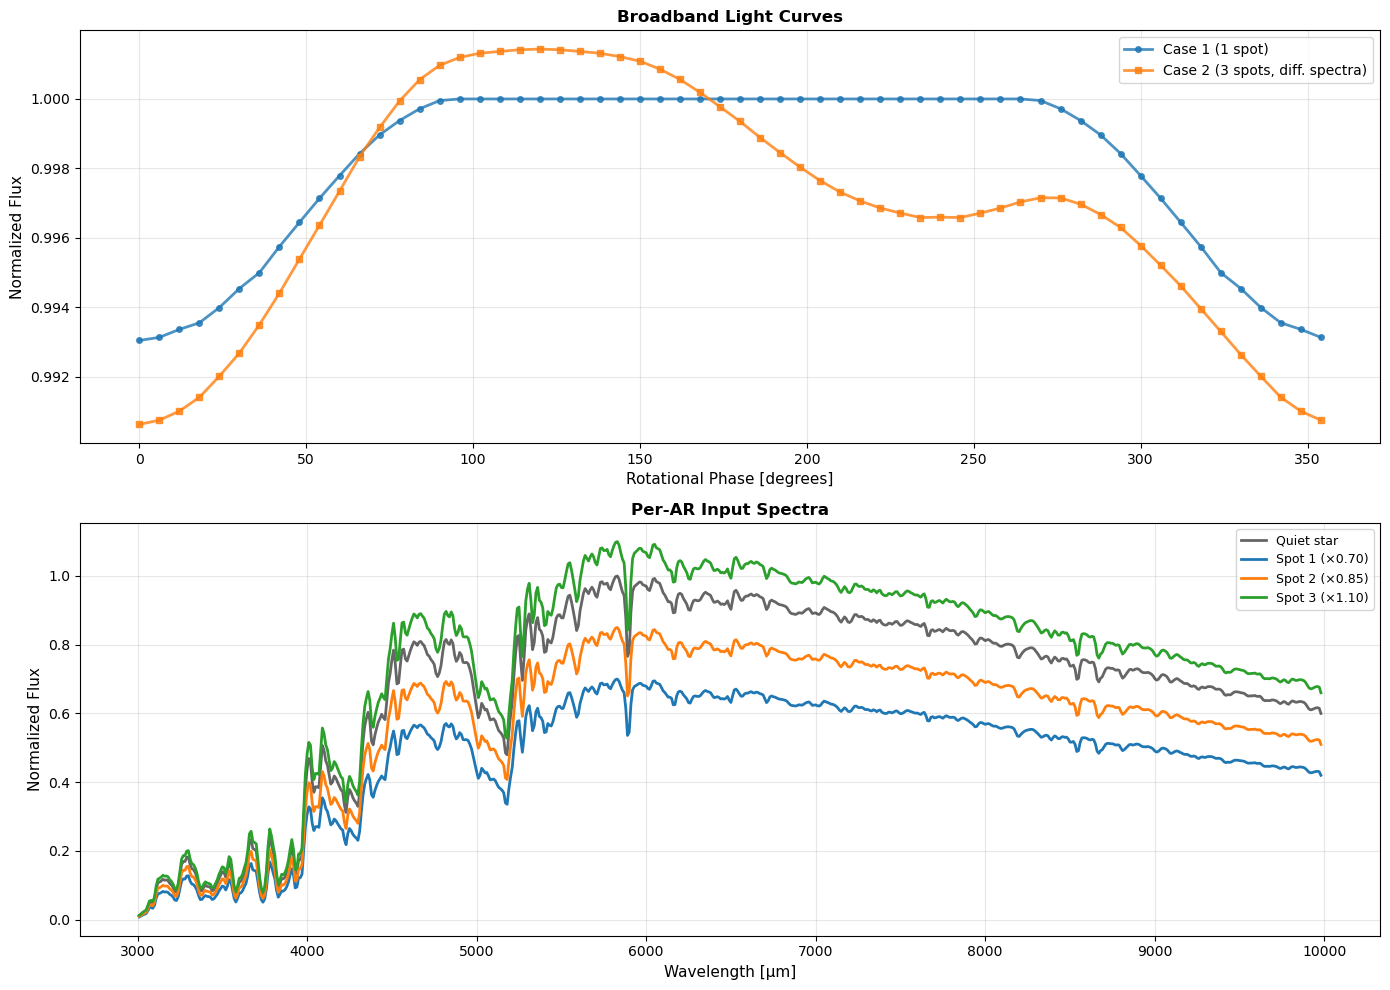


Results:
  Case 1 amplitude:        6949.60 ppm
  Case 2 amplitude:        10800.66 ppm
  Amplitude change:        +55.4%
  Note: Spot 3 is a facula (scale=1.10 > 1), which partially cancels the cold spots.


In [5]:
print("\n" + "="*60)
print("CASE 2: Multiple Spots")
print("="*60)

# --- each spot gets a scaled version of the active-region spectrum ---
# Spot 1: strong cold spot       (70% of quiet flux)
# Spot 2: moderate cool spot     (85% of quiet flux)
# Spot 3: mild warm spot / facula (110% of quiet flux)
scale_factors = [0.70, 0.85, 1.10]

# Build (nar, nwave) flux array — each row is the active spectrum
# scaled relative to the quiet spectrum
flux_active_multi = np.stack([
    s * flux_quiet for s in scale_factors
])  # shape (3, nwave)

print("Per-AR flux scaling factors:", scale_factors)
print(f"flux_active_multi shape:     {flux_active_multi.shape}")

result_case2 = compute_light_curve(
    wavelength          = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active_multi,
    params              = params_case1,
    ar_lat              = [30.0, -20.0, 5.0],        # Three spots
    ar_long             = [0.0, 120.0, 240.0],
    ar_size             = [10.0, 8.0, 6.0],                     
    phases_rot          = np.linspace(0, 360, 60, endpoint=False),
    stellar_grid_size   = 100,      # stellar radius in pixels
    ve                  = 2.0,
    ldc_mode            = "quadratic",
)

fig, axes = plt.subplot_mosaic([['A', 'A'], ['B', 'B']], figsize=(14, 10))

# Top: Compare single-spectrum vs multi-spectrum light curves
ax = axes['A']
ax.plot(phases, result_case1["lc"], 'o-', label='Case 1 (1 spot)',
        linewidth=2, markersize=4, alpha=0.8)
ax.plot(phases, result_case2["lc"], 's-', label='Case 2 (3 spots, diff. spectra)',
        linewidth=2, markersize=4, alpha=0.8)
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Broadband Light Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom: Input spectra for each AR
ax = axes['B']
ax.plot(wavelength, flux_quiet, 'k-', linewidth=2, label='Quiet star', alpha=0.6)
for i, (s, c) in enumerate(zip(scale_factors, ['#1f77b4', '#ff7f0e', '#2ca02c'])):
    ax.plot(wavelength, flux_active_multi[i], '-', linewidth=2, color=c,
            label=f'Spot {i+1} (×{s:.2f})')
ax.set_xlabel('Wavelength [μm]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Per-AR Input Spectra', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

lc_amp_2 = np.max(result_case2["lc"]) - np.min(result_case2["lc"])
print(f"\nResults:")
print(f"  Case 1 amplitude:        {lc_amplitude*1e6:.2f} ppm")
print(f"  Case 2 amplitude:        {lc_amp_2*1e6:.2f} ppm")
print(f"  Amplitude change:        {(lc_amp_2 - lc_amplitude)/lc_amplitude * 100:+.1f}%")
print(f"  Note: Spot 3 is a facula (scale={scale_factors[2]:.2f} > 1), "
      f"which partially cancels the cold spots.")

## Case 3 - Different Stellar Inclinations


CASE 3: Effect of Stellar Inclination
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 698 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)


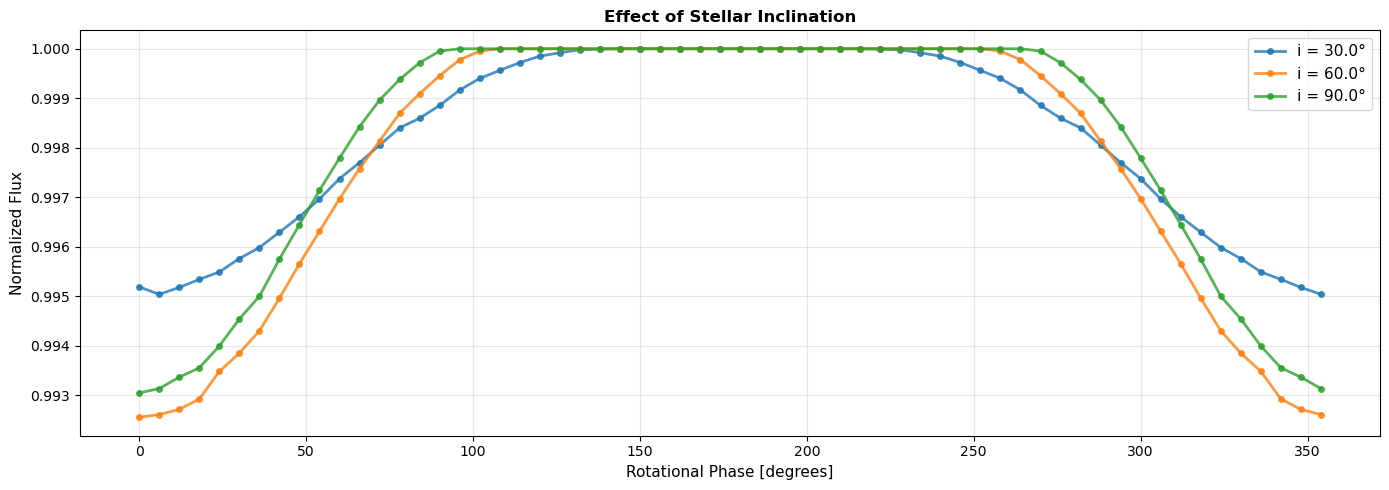


Amplitudes vs Inclination:
  i =  30.0°:  4959.29 ppm
  i =  60.0°:  7441.94 ppm
  i =  90.0°:  6949.60 ppm


In [6]:
print("\n" + "="*60)
print("CASE 3: Effect of Stellar Inclination")
print("="*60)

inclinations = [30.0, 60.0, 90.0]  # pole-on to equator-on
results_inc = []

for inc in inclinations:
    params_inc = dict(
        ldc_coeffs = [u1_mean, u2_mean],
        inc_star   = inc,
    )
    result = compute_light_curve(
        wavelength          = wavelength,
        flux_quiet          = flux_quiet,
        flux_active         = flux_active,
        params              = params_inc,
        ar_lat              = [20.0],
        ar_long             = [0.0],
        ar_size             = [5.0],                     # 5° radius
        phases_rot          = np.linspace(0, 360, 60, endpoint=False),
        stellar_grid_size   = 100,      # stellar radius in pixels
        ve                  = 2.0,
        ldc_mode            = "quadratic",
    )
    results_inc.append(result)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Plot: LC vs inclination
for i, inc in enumerate(inclinations):
    ax.plot(phases, results_inc[i]["lc"], 'o-', label=f'i = {inc}°', 
            linewidth=2, markersize=4, alpha=0.8)
ax.set_xlabel('Rotational Phase [degrees]', fontsize=11)
ax.set_ylabel('Normalized Flux', fontsize=11)
ax.set_title('Effect of Stellar Inclination', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAmplitudes vs Inclination:")
amplitudes = [np.max(r["lc"]) - np.min(r["lc"]) for r in results_inc]

for inc, amp in zip(inclinations, amplitudes):
    print(f"  i = {inc:5.1f}°:  {amp*1e6:6.2f} ppm")

## Case 4 - Wavelength-Dependent Limb-Darkening


CASE 4: Wavelength-Dependent LD Coefficients
build_model: per-wavelength LDCs provided for 'quadratic' law (2 coefficient(s), 698 wavelength bins).
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)


/var/folders/zb/dzv8y8kn1dl5qhcybvz_4nv00000gn/T/ipykernel_20355/3355349227.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


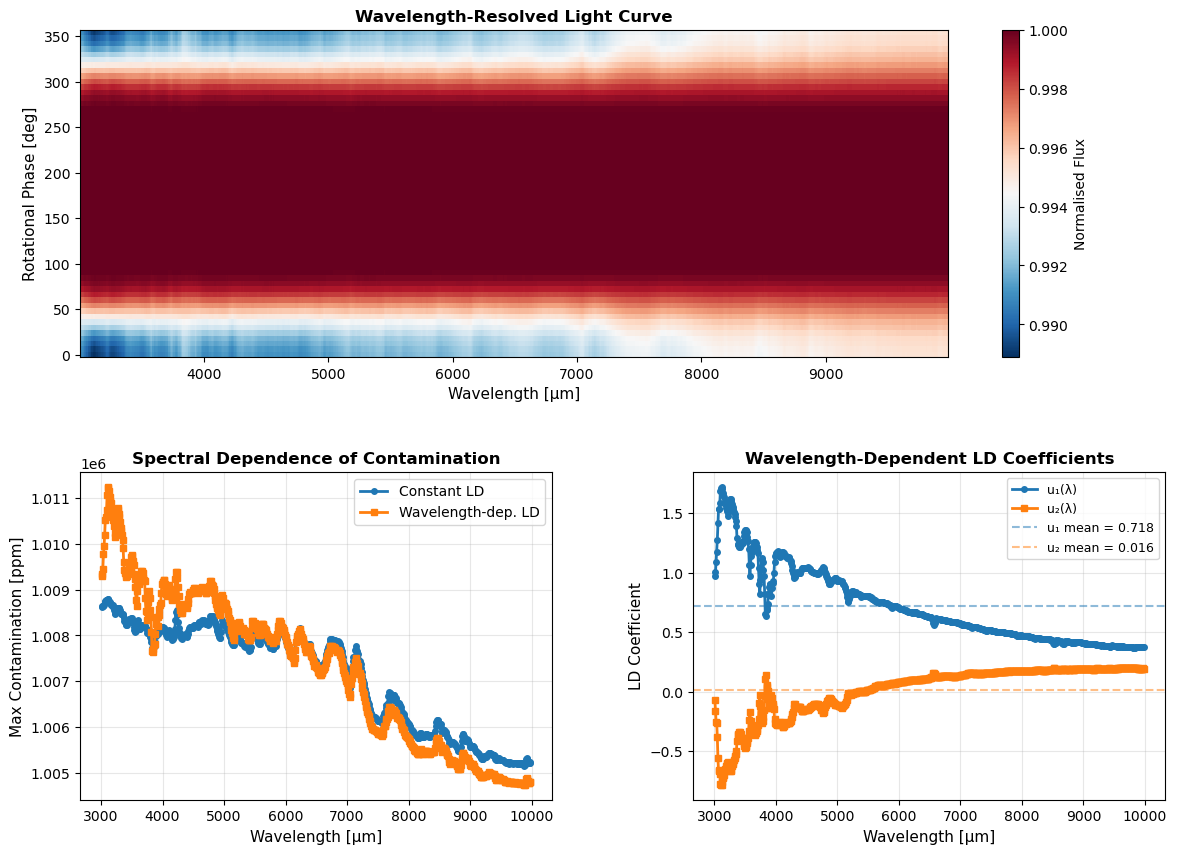


Results:
  Constant LD amplitude:        6949.60 ppm
  Wavelength-dep. LD amplitude: 6824.73 ppm
  Difference:                   -1.8%


In [7]:
print("\n" + "="*60)
print("CASE 4: Wavelength-Dependent LD Coefficients")
print("="*60)

params_case4 = dict(
    ldc_coeffs = [u1_wavelength, u2_wavelength],   # each is (nwave,)
    inc_star   = 90.0,
)

result_case4 = compute_light_curve(
    wavelength          = wavelength,
    flux_quiet          = flux_quiet,
    flux_active         = flux_active,
    params              = params_case4,
    ar_lat              = [20.0],
    ar_long             = [0.0],
    ar_size             = [5.0],                     
    phases_rot          = np.linspace(0, 360, 60, endpoint=False),
    stellar_grid_size   = 100,      
    ve                  = 2.0,
    ldc_mode            = "quadratic",
)

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], hspace=0.35, wspace=0.3)

# ------------------------------------------------------------------
# Top (spans both columns): Wavelength-resolved LC heatmap
# ------------------------------------------------------------------
ax_top = fig.add_subplot(gs[0, :])

# Build the per-wavelength light curves from the contamination factor.
# Recall:  ε(φ, λ) = F_quiet(λ) / F_spotted(λ)
# So the per-wavelength normalised flux is:  f(φ, λ) = 1 / ε(φ, λ)
epsilon4    = result_case4["epsilon"]                   # (nphase, nwave)
flux_wl_map = 1.0 / np.where(epsilon4 == 0, 1.0, epsilon4)  # avoid div/0

im = ax_top.pcolormesh(
    wavelength, phases, flux_wl_map,
    shading='auto', cmap='RdBu_r',
)
ax_top.set_xlabel('Wavelength [μm]', fontsize=11)
ax_top.set_ylabel('Rotational Phase [deg]', fontsize=11)
ax_top.set_title(
    'Wavelength-Resolved Light Curve',
    fontsize=12, fontweight='bold',
)
cbar = plt.colorbar(im, ax=ax_top, label='Normalised Flux')

# ------------------------------------------------------------------
# Bottom-left: Max contamination per wavelength
# ------------------------------------------------------------------
ax_bl = fig.add_subplot(gs[1, 0])

max_cont_const = np.max(result_case1["epsilon"], axis=0) * 1e6
max_cont_wldep = np.max(result_case4["epsilon"], axis=0) * 1e6
ax_bl.plot(wavelength, max_cont_const, 'o-', label='Constant LD',
           linewidth=2, markersize=4)
ax_bl.plot(wavelength, max_cont_wldep, 's-', label='Wavelength-dep. LD',
           linewidth=2, markersize=4)
ax_bl.set_xlabel('Wavelength [μm]', fontsize=11)
ax_bl.set_ylabel('Max Contamination [ppm]', fontsize=11)
ax_bl.set_title('Spectral Dependence of Contamination',
                fontsize=12, fontweight='bold')
ax_bl.legend(fontsize=10)
ax_bl.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# Bottom-right: LD coefficient variation with wavelength
# ------------------------------------------------------------------
ax_br = fig.add_subplot(gs[1, 1])

ax_br.plot(wavelength, u1_wavelength, 'o-', label='u₁(λ)',
           linewidth=2, markersize=4)
ax_br.plot(wavelength, u2_wavelength, 's-', label='u₂(λ)',
           linewidth=2, markersize=4)
ax_br.axhline(u1_mean, color='C0', linestyle='--', alpha=0.5,
              label=f'u₁ mean = {u1_mean:.3f}')
ax_br.axhline(u2_mean, color='C1', linestyle='--', alpha=0.5,
              label=f'u₂ mean = {u2_mean:.3f}')
ax_br.set_xlabel('Wavelength [μm]', fontsize=11)
ax_br.set_ylabel('LD Coefficient', fontsize=11)
ax_br.set_title('Wavelength-Dependent LD Coefficients',
                fontsize=12, fontweight='bold')
ax_br.legend(fontsize=9)
ax_br.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

lc_amp_4 = np.max(result_case4["lc"]) - np.min(result_case4["lc"])
print(f"\nResults:")
print(f"  Constant LD amplitude:        {lc_amplitude*1e6:.2f} ppm")
print(f"  Wavelength-dep. LD amplitude: {lc_amp_4*1e6:.2f} ppm")
print(f"  Difference:                   "
      f"{(lc_amp_4 - lc_amplitude)/lc_amplitude * 100:+.1f}%")

## Case 5 — Planet Transit with Active-Region Crossing

This case demonstrates how to use `compute_combined_light_curve` to include a planetary transit.
The planet's occultation mask is applied **at the pixel level** inside sajax's
flux integrator, so when the planet crosses a starspot the flux anomaly
(the "spot-crossing bump") emerges automatically — no post-multiplication needed.

We place a cold spot directly on the transit chord and compare three scenarios:
1. **Transit only** — quiet star, no active regions.
2. **Stellar activity only** — spot visible, no transit.
3. **Combined** — transit crossing the spot; the bump is clearly visible.


CASE 5: Planet Transit + Active-Region Crossing
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 1 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 1 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)
build_model: scalar LDCs provided for 'quadratic' law ([0.7184, 0.0164]) — broadcasting across all 1 wavelength bins.
build_model: active region overlap mode: 'hottest_wins' (overlaps take flux from hottest AR)


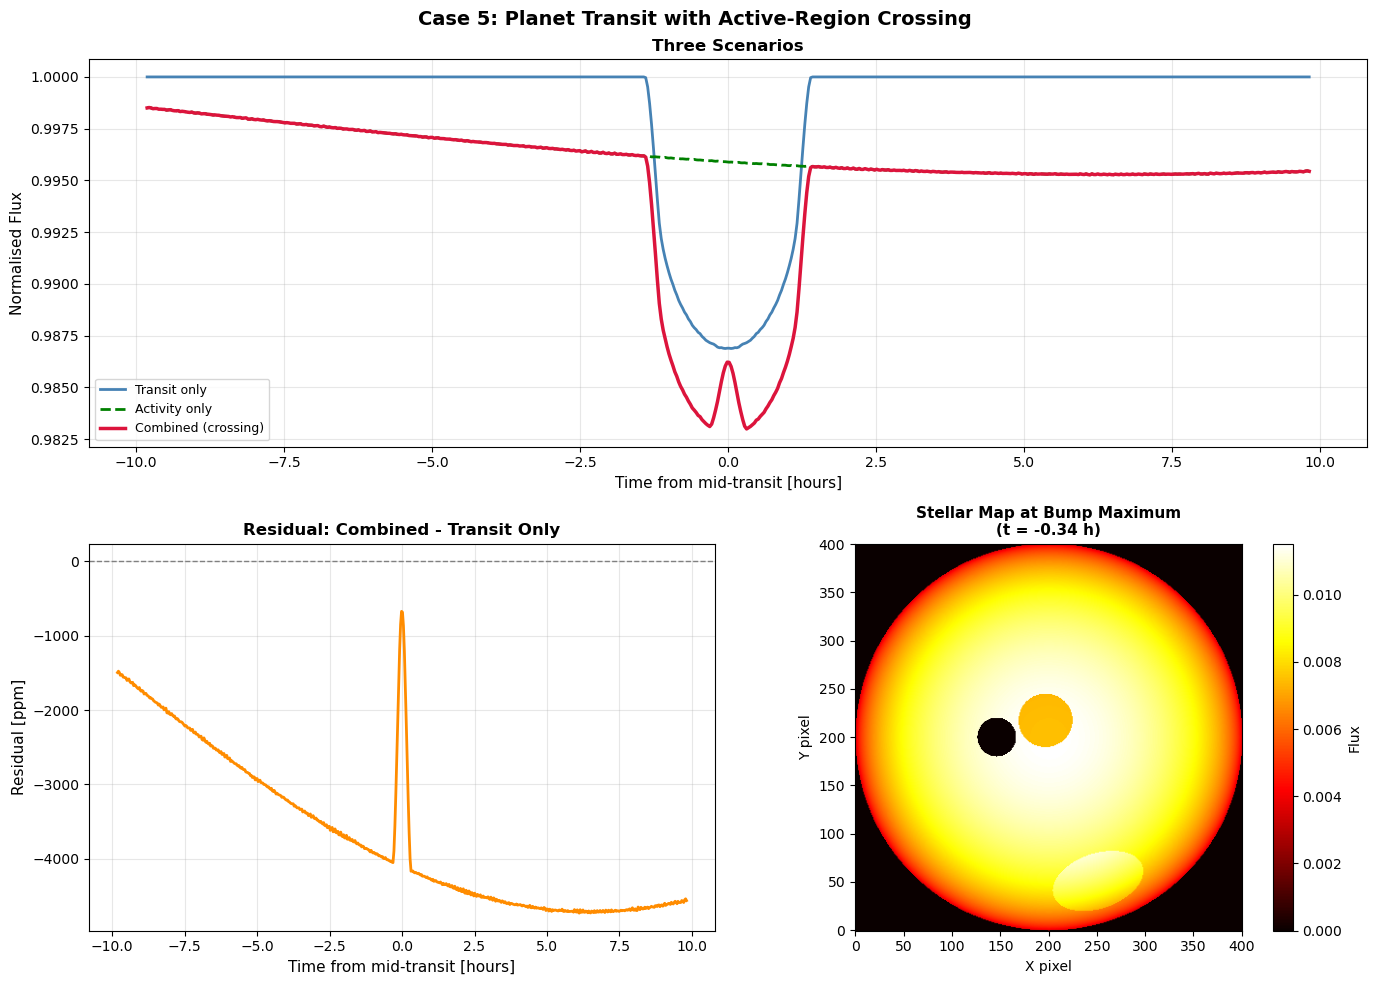

In [8]:
print("\n" + "="*60)
print("CASE 5: Planet Transit + Active-Region Crossing")
print("="*60)

# ------------------------------------------------------------------
# Time array: ±3.5× the approximate transit duration
# ------------------------------------------------------------------
# For a/R* = 15, k = 0.1, i = 90°, P = 5 d, T14 ≈ P/π * arcsin(1/a) ≈ 0.21 d
T14_approx = 5.0 / np.pi * np.arcsin((1.0 + 0.1) / 15.0)
times = np.linspace(-3.5 * T14_approx, 3.5 * T14_approx, 600)

# ------------------------------------------------------------------
# Stellar & orbital parameters
# ------------------------------------------------------------------
P_ROT = 5.0               # long rotation period → negligible out-of-transit modulation
STELLAR_GRID = 200         # stellar radius in pixels

transit_params = dict(
    t0           = 0.0,
    period       = 5.0,
    a_over_rstar = 15.0,
    inclination  = np.pi / 2.0,    # perfectly edge-on
    k            = 0.1,            # Rp/R* = 0.1  →  depth ≈ 1%
    ecc          = 0.0,
    omega_peri   = 0.0,
)

params_sajax = dict(
    ldc_coeffs = [u1_mean, u2_mean],   # quadratic limb darkening (from earlier cells)
    inc_star   = 90.0,                 # equator-on stellar view
)
# ------------------------------------------------------------------
# Active-region configuration: cold spot on transit chord
# ------------------------------------------------------------------
# Spot at lat=0°, long=0° — faces the observer at t=0 (mid-transit)
# so the planet crosses directly over it.
spot_flux   = 0.65 * flux_quiet[0]          # 35% darker than quiet
facula_flux = 1.15 * flux_quiet[0]          # 15% brighter than quiet

# ------------------------------------------------------------------
# Scenario 1: Transit only (no active region)
# ------------------------------------------------------------------
result_transit_only = compute_combined_light_curve(
    wavelength        = [wavelength[0]],
    flux_quiet        = [flux_quiet[0]],
    flux_active       = np.stack([[spot_flux], [facula_flux]]),  
    params            = params_sajax,
    ar_lat            = [5.0, -50],
    ar_long           = [0.0, 25.0],                 
    ar_size           = [0.0001, 0.0001],      # Make 
    times             = times,
    P_rot             = P_ROT,
    transit_params    = transit_params,
    stellar_grid_size = STELLAR_GRID,
    ve                = 2.0,
    ldc_mode          = "quadratic",
)

# ------------------------------------------------------------------
# Scenario 2: Stellar activity only (no transit, k → 0)
# ------------------------------------------------------------------
tp_no_transit = {**transit_params, "k": 0.0}  # zero-radius planet — no occultation

result_activity_only = compute_combined_light_curve(
    wavelength        = [wavelength[0]],
    flux_quiet        = [flux_quiet[0]],
    flux_active       = np.stack([[spot_flux], [facula_flux]]),  
    params            = params_sajax,
    ar_lat            = [5.0, -50],
    ar_long           = [0.0, 25.0],                 
    ar_size           = [8.0, 14.0],
    times             = times,
    P_rot             = P_ROT,
    transit_params    = tp_no_transit,
    stellar_grid_size = STELLAR_GRID,
    ve                = 2.0,
    ldc_mode          = "quadratic",
)

# ------------------------------------------------------------------
# Scenario 3: Combined — transit crosses the spot
# ------------------------------------------------------------------
result_combined = compute_combined_light_curve(
    wavelength        = [wavelength[0]],
    flux_quiet        = [flux_quiet[0]],
    flux_active       = np.stack([[spot_flux], [facula_flux]]),  
    params            = params_sajax,
    ar_lat            = [5.0, -50],
    ar_long           = [0.0, 25.0],                 
    ar_size           = [8.0, 14.0],
    times             = times,
    P_rot             = P_ROT,
    transit_params    = transit_params,
    stellar_grid_size = STELLAR_GRID,
    ve                = 2.0,
    ldc_mode          = "quadratic",
)

lc_transit   = result_transit_only["lc"]
lc_activity  = result_activity_only["lc"]
lc_combined  = result_combined["lc"]

# ------------------------------------------------------------------
# Plotting
# ------------------------------------------------------------------
fig, axes = plt.subplot_mosaic([['A', 'A'],['B', 'C']], figsize=(14, 10))
fig.suptitle("Case 5: Planet Transit with Active-Region Crossing",
             fontsize=14, fontweight="bold")

# ---- Top: all three scenarios ----------------------------------
ax = axes['A']
ax.plot(times * 24, lc_transit,  lw=2,   color="steelblue",  label="Transit only")
ax.plot(times * 24, lc_activity, lw=2,   color="green",      label="Activity only", linestyle="--")
ax.plot(times * 24, lc_combined, lw=2.5, color="crimson",    label="Combined (crossing)", zorder=5)
ax.set_xlabel("Time from mid-transit [hours]", fontsize=11)
ax.set_ylabel("Normalised Flux", fontsize=11)
ax.set_title("Three Scenarios", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Bottom-left: residual (combined − transit only) ----------------
ax = axes['B']
residual = lc_combined - lc_transit
ax.plot(times * 24, residual * 1e6, lw=2, color="darkorange")
ax.axhline(0, color="grey", lw=1, linestyle="--")
ax.set_xlabel("Time from mid-transit [hours]", fontsize=11)
ax.set_ylabel("Residual [ppm]", fontsize=11)
ax.set_title("Residual: Combined - Transit Only", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)

# ---- Bottom-right: stellar flux map during spot crossing ------------
ax = axes['C']
# Find the phase index closest to the bump maximum
star_maps   = result_combined["star_maps"]
all_times   = times
bump_t_idx  = int(np.argmax(residual))-10      # time of maximum spot-crossing anomaly
map_data    = star_maps[bump_t_idx]
im = ax.imshow(map_data, cmap="hot", origin="lower", vmin=0)
ax.set_title(
    f"Stellar Map at Bump Maximum\n(t = {times[bump_t_idx]*24:+.2f} h)",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("X pixel", fontsize=10)
ax.set_ylabel("Y pixel", fontsize=10)
plt.colorbar(im, ax=ax, label="Flux")

plt.tight_layout()
plt.show()
